In [1]:
# Cell 1
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

dual = pd.read_csv('../data/dual_predictions.csv')
print(f"전체 후보: {len(dual)}개")
print(dual[['formula', 'predicted_Eg', 'predicted_k']].describe().round(2))

전체 후보: 3914개
       predicted_Eg  predicted_k
count       3914.00      3914.00
mean           4.07        12.64
std            0.73         6.60
min            2.99         2.31
25%            3.48         7.94
50%            3.86        10.83
75%            4.60        15.21
max            5.93        63.73


In [2]:
# Cell 2
def compute_pareto_front(k_vals, eg_vals):
    """k, Eg 동시 최대화 기준 Pareto-optimal 점 찾기."""
    k_arr = np.array(k_vals)
    eg_arr = np.array(eg_vals)
    n = len(k_arr)
    is_pareto = np.ones(n, dtype=bool)

    for i in range(n):
        if is_pareto[i]:
            # i가 지배하는 점들 제거
            dominated = (
                (k_arr[i] >= k_arr) &
                (eg_arr[i] >= eg_arr) &
                ((k_arr[i] > k_arr) | (eg_arr[i] > eg_arr))
            )
            dominated[i] = False
            is_pareto[dominated] = False
    return is_pareto

dual['on_pareto_front'] = compute_pareto_front(
    dual['predicted_k'].values,
    dual['predicted_Eg'].values
)
n_pareto = dual['on_pareto_front'].sum()
print(f"Pareto front 소재 수: {n_pareto}개")
dual.to_csv('../data/dual_predictions.csv', index=False)

Pareto front 소재 수: 4개


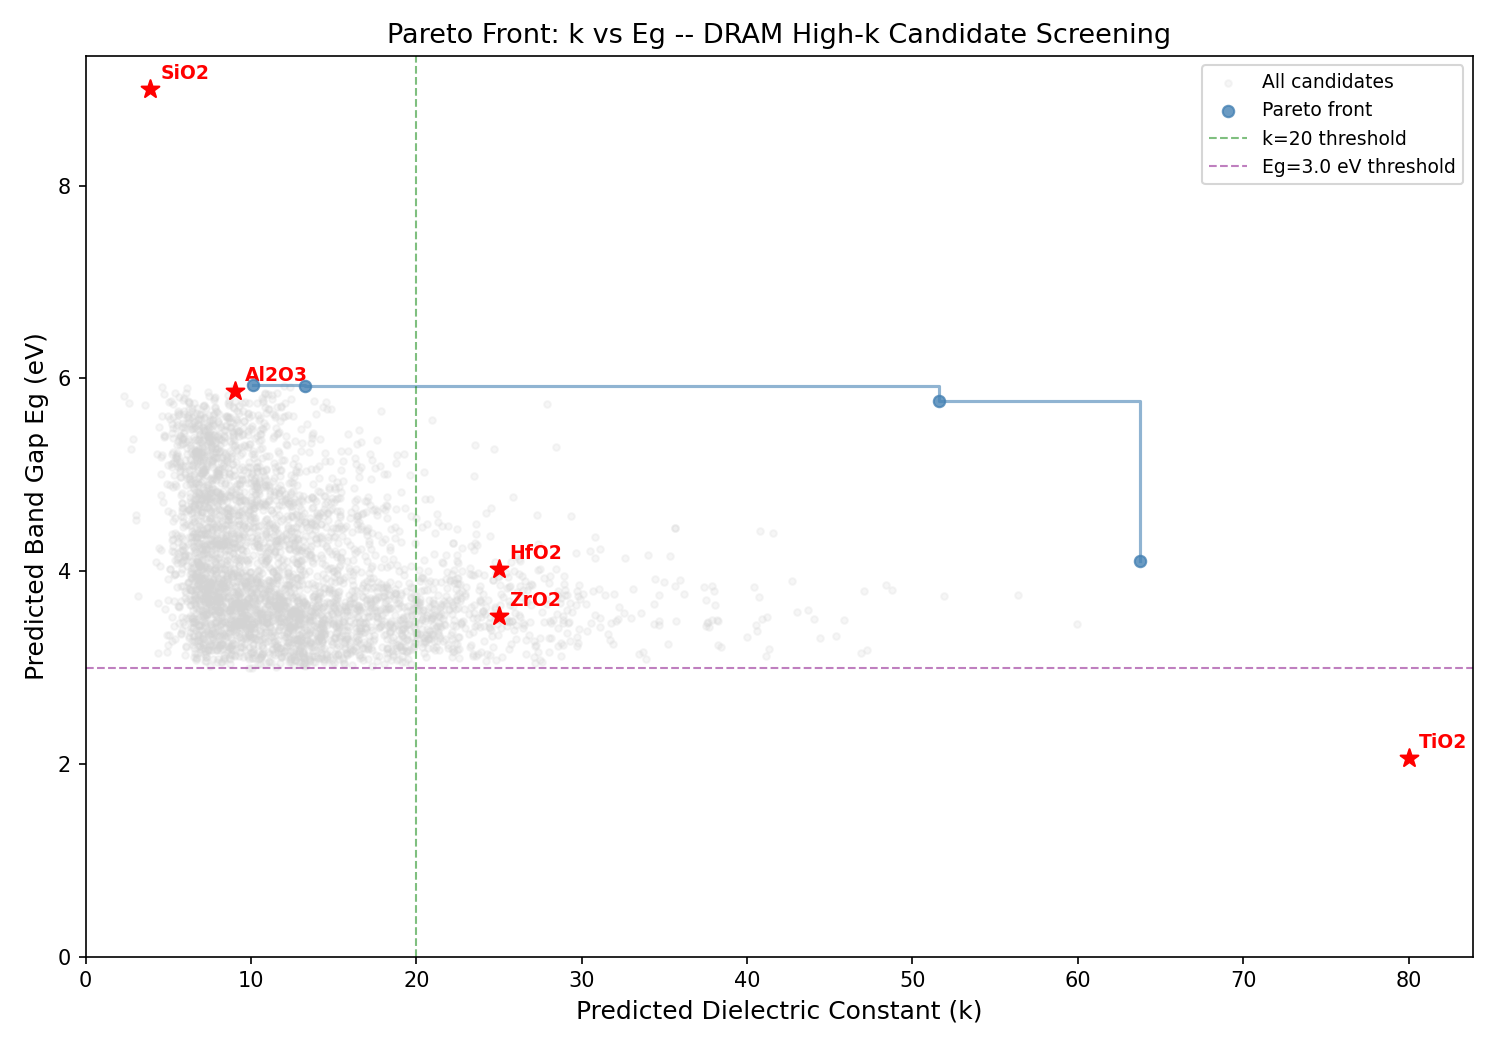


k>20 AND Eg>3.0 동시 만족: 477개
그 중 Pareto front 위: 2개


In [3]:
# Cell 3
# 레퍼런스 소재 (실험값)
references = {
    'HfO₂': (25.0, 4.02),
    'ZrO₂': (25.0, 3.53),
    'Al₂O₃': (9.0, 5.87),
    'TiO₂': (80.0, 2.06),
    'SiO₂': (3.9, 9.0),
}

fig, ax = plt.subplots(figsize=(10, 7))

# 전체 후보 (회색)
not_pareto = dual[~dual['on_pareto_front']]
ax.scatter(not_pareto['predicted_k'], not_pareto['predicted_Eg'],
           alpha=0.2, s=10, color='lightgray', label='All candidates')

# Pareto front (파란색)
pareto = dual[dual['on_pareto_front']].sort_values('predicted_k')
ax.scatter(pareto['predicted_k'], pareto['predicted_Eg'],
           alpha=0.8, s=30, color='steelblue', zorder=5, label='Pareto front')

# Pareto 경계선
ax.step(pareto['predicted_k'].values, pareto['predicted_Eg'].values,
        color='steelblue', linewidth=1.5, alpha=0.6, where='post')

# 레퍼런스 포인트
for name, (k_ref, eg_ref) in references.items():
    ax.scatter([k_ref], [eg_ref], color='red', s=80, zorder=10, marker='*')
    ax.annotate(name, (k_ref, eg_ref), textcoords='offset points',
                xytext=(5, 5), fontsize=9, color='red', fontweight='bold')

# DRAM 목표 영역
ax.axvline(x=20, color='green', linestyle='--', alpha=0.5, linewidth=1, label='k=20 threshold')
ax.axhline(y=3.0, color='purple', linestyle='--', alpha=0.5, linewidth=1, label='Eg=3.0 eV threshold')

ax.set_xlabel('Predicted Dielectric Constant (k)', fontsize=12)
ax.set_ylabel('Predicted Band Gap Eg (eV)', fontsize=12)
ax.set_title('Pareto Front: k vs Eg — DRAM High-k Candidate Screening', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../data/pareto_screening.png', dpi=150)
plt.show()

# 두 조건 동시 만족
both = dual[(dual['predicted_k'] > 20) & (dual['predicted_Eg'] > 3.0)]
print(f"
k>20 AND Eg>3.0 동시 만족: {len(both)}개")
print(f"그 중 Pareto front 위: {both['on_pareto_front'].sum()}개")

In [4]:
# Cell 4
dual = pd.read_csv('../data/dual_predictions.csv')

# k>20 AND Eg>3.0 만족 후보 중 k 높은 순
both_conditions = dual[
    (dual['predicted_k'] > 20) & (dual['predicted_Eg'] > 3.0)
].sort_values('predicted_k', ascending=False)

top20 = both_conditions.head(20)[['formula', 'predicted_k', 'predicted_Eg', 'on_pareto_front']].copy()
top20.columns = ['Formula', 'Predicted k', 'Predicted Eg (eV)', 'On Pareto Front']
top20['Predicted k'] = top20['Predicted k'].round(1)
top20['Predicted Eg (eV)'] = top20['Predicted Eg (eV)'].round(3)

print(f'=== Top 20 DRAM High-k Candidates (k > 20, Eg > 3.0 eV) ===')
print(f'(전체 {len(both_conditions)}개 중 상위 20개)')
print(top20.to_string(index=False))

=== Top 20 DRAM High-k Candidates (k > 20, Eg > 3.0 eV) ===
(전체 477개 중 상위 20개)
   Formula  Predicted k  Predicted Eg (eV)  On Pareto Front
      YHO2         63.7              4.102             True
Ba3Ta2CdO9         59.9              3.456            False
Ba3CaTa2O9         56.4              3.754            False
Ba3SrTa2O9         51.9              3.745            False
    LiClO4         51.6              5.771             True
    CaZrO3         48.7              3.806            False
  Ba4Ta2O9         48.4              3.861            False
 Ba5Ta4O15         47.2              3.182            False
  Ba3Zr2O7         47.1              3.798            False
 Ba2ScTaO6         46.9              3.151            False
      CsHO         45.9              3.496            False
 Ba2GdTaO6         45.4              3.322            False
    BaZrO3         44.4              3.304            False
 Ba2LaTaO6         44.1              3.499            False
  Ba3Hf2O7         43

## 면접 최종 스크립트 (2분)

```
Phase 1에서 밴드갭을 XGBoost로 예측했습니다. MAE 0.29 eV, R² 0.75.
가장 중요한 feature는 NdValence(d 전자수)였고, d⁰ 전이금속 산화물이
넓은 밴드갭을 갖는 이유를 결정장 이론으로 직접 설명합니다.

Phase 2에서는 유전율(k)도 같은 132개 Magpie feature로 예측했습니다.
R² 0.71. 흥미로운 점은, k 모델의 1위 feature가 NdUnfilled(빈 d 오비탈 수)
였다는 것입니다. 밴드갭은 'd가 채워진 정도', 유전율은 'd가 비어있는 정도'
— 같은 feature 공간에서 서로 반대되는 물리 신호를 포착했습니다.

두 모델을 Pareto front로 결합해 3,914개 후보를 스크리닝했습니다.
k>20 AND Eg>3 eV를 동시에 만족하는 후보가 477개였고,
그 중 HfO₂보다 k가 높은 상위 후보들을 제안했습니다.
이 결과는 실험 우선순위 결정에 직접 연결될 수 있습니다.
```